In [125]:
import pandas as pd
import numpy as np
np.set_printoptions(threshold=np.inf)

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from datasets import load_dataset

from huggingface_hub import hf_hub_download

In [126]:
csv_data_df = pd.read_csv("../data-processing/events.csv")
csv_data_df.rename(columns={"Unnamed: 0":"ACN"}, inplace=True)
csv_data_df.head()

,ACN,assessments_primary_problem,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,20,21,22,23
0,2260174,ambiguous,anomaly_inflight_event_/_encounter_unstabilize...,anomaly_atc_issue_all_types,anomaly_deviation_/_discrepancy_-_procedural_p...,anomaly_inflight_event_/_encounter_cftt_/_cfit,detector_person_air_traffic_control,when_detected_in_flight,result_general_none_reported_/_taken,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2260249,ambiguous,anomaly_aircraft_equipment_problem_critical,anomaly_inflight_event_/_encounter_cftt_/_cfit,detector_person_flight_crew,detector_automation_aircraft_other_automation,when_detected_in_flight,result_flight_crew_flc_complied_w_/_automation...,result_flight_crew_executed_go_around_/_missed...,result_flight_crew_became_reoriented,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2260370,aircraft,anomaly_deviation_/_discrepancy_-_procedural_w...,anomaly_aircraft_equipment_problem_critical,anomaly_deviation_/_discrepancy_-_procedural_p...,detector_person_flight_crew,when_detected_in_flight,result_air_traffic_control_provided_assistance,result_aircraft_aircraft_damaged,result_flight_crew_diverted,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2261277,human_factors,anomaly_deviation_/_discrepancy_-_procedural_far,anomaly_conflict_airborne_conflict,anomaly_deviation_/_discrepancy_-_procedural_u...,anomaly_deviation_/_discrepancy_-_procedural_p...,anomaly_airspace_violation_all_types,detector_person_flight_crew,when_detected_in_flight,result_general_none_reported_/_taken,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2261317,procedure,anomaly_deviation_-_track_/_heading_all_types,anomaly_inflight_event_/_encounter_loss_of_air...,anomaly_deviation_/_discrepancy_-_procedural_p...,anomaly_inflight_event_/_encounter_weather_/_t...,anomaly_deviation_-_speed_all_types,detector_person_flight_crew,detector_automation_aircraft_other_automation,when_detected_in_flight,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
# Aggregate the events into one list to be used by the onehot encoder
aggregate_events_list = csv_data_df[csv_data_df.columns[2:]].agg(list, axis=1)

# Drop NaN entries (there's probably a cleaner way to do this)
for i in range(len(aggregate_events_list)): 
    for j in range(len(aggregate_events_list[i])):
        if not isinstance(aggregate_events_list[i][j], str):
            aggregate_events_list[i] = aggregate_events_list[i][:j]
            break

aggregate_events_list.head()

0    [anomaly_inflight_event_/_encounter_unstabiliz...
1    [anomaly_aircraft_equipment_problem_critical, ...
2    [anomaly_deviation_/_discrepancy_-_procedural_...
3    [anomaly_deviation_/_discrepancy_-_procedural_...
4    [anomaly_deviation_-_track_/_heading_all_types...
dtype: object

In [128]:
# Create a new dataframe with all events aggregated into a list (to be used by the onehotter)
aggregate_events_df = pd.DataFrame(csv_data_df[csv_data_df.columns[:2]])
aggregate_events_df["events"] = aggregate_events_list
aggregate_events_df.head()

,ACN,assessments_primary_problem,events
0,2260174,ambiguous,[anomaly_inflight_event_/_encounter_unstabiliz...
1,2260249,ambiguous,"[anomaly_aircraft_equipment_problem_critical, ..."
2,2260370,aircraft,[anomaly_deviation_/_discrepancy_-_procedural_...
3,2261277,human_factors,[anomaly_deviation_/_discrepancy_-_procedural_...
4,2261317,procedure,[anomaly_deviation_-_track_/_heading_all_types...


### One Hotting The Data

In [129]:
ohe = OneHotEncoder()   # <-- This is unnecessary
mlb = MultiLabelBinarizer()

In [130]:
onehotted = mlb.fit_transform(aggregate_events_df.events)
onehot_events_df = pd.DataFrame(onehotted, columns=mlb.classes_)

# Combine into one dataframe with the ACN and primary problem
onehot_events_df = pd.concat([aggregate_events_df[aggregate_events_df.columns[:2]], onehot_events_df], axis=1)
onehot_events_df.set_index("ACN", inplace=True)
onehot_events_df.head()

,assessments_primary_problem,anomaly_aircraft_equipment_problem_critical,anomaly_aircraft_equipment_problem_less_severe,anomaly_airspace_violation_all_types,anomaly_atc_issue_all_types,anomaly_conflict_airborne_conflict,anomaly_conflict_ground_conflict,anomaly_conflict_nmac,anomaly_critical,anomaly_deviation_-_altitude_crossing_restriction_not_met,...,when_detected_not_stated,when_detected_postflight,when_detected_preflight,when_detected_pushback,when_detected_routine_inspection,when_detected_takeoff,when_detected_takeoff_roll,when_detected_taxi,when_detected_towing,when_detected_unknown
ACN,,,,,,,,,,,,,,,,,,,,,
2260174,ambiguous,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2260249,ambiguous,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2260370,aircraft,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2261277,human_factors,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2261317,procedure,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [131]:
# Load dataset splits
train_dataset = load_dataset("sookiemonster/asrs-narratives", split="train")
validation_dataset = load_dataset("sookiemonster/asrs-narratives", split="validation")
test_dataset = load_dataset("sookiemonster/asrs-narratives", split="test")

train_acns = set(train_dataset["acn"])
validation_acns = set(validation_dataset["acn"])
test_acns = set(test_dataset["acn"])

print(len(train_acns))
print(len(validation_acns))
print(len(test_acns))

10360
4441
9868


In [132]:
# Split up the main dataframe
train_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(train_acns)]
validation_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(validation_acns)]
test_events_df = onehot_events_df.iloc[onehot_events_df.index.isin(test_acns)]

# Lengths don't match because I removed empty rows from the events dataset, might be something to consider to improve the model 
print(len(train_events_df))
print(len(validation_events_df))
print(len(test_events_df))

10293
4415
9826


### Model (Base)

In [133]:
trainX = train_events_df.drop(columns="assessments_primary_problem")
trainY = train_events_df["assessments_primary_problem"]

testX = test_events_df.drop(columns="assessments_primary_problem")
testY = test_events_df["assessments_primary_problem"]

In [134]:
rfc = RandomForestClassifier()
nbc = MultinomialNB()

In [135]:
rfc.fit(trainX, trainY)
nbc.fit(trainX, trainY)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Model Evaluation

In [136]:
# Download visualization tools from our huggingface repo
hf_hub_download(repo_id="sookiemonster/asrs-narratives", filename="utils.py", repo_type="dataset", local_dir=".")

from utils import visualize_eval

In [137]:
print("Random Forest Score:", rfc.score(testX, testY))
print("Naive Bayes Score:", nbc.score(testX, testY))

Random Forest Score: 0.6600854874821901
Naive Bayes Score: 0.5823325870140443


                                              precision    recall  f1-score   support

                                    aircraft       0.82      0.93      0.87      3286
                                     airport       0.42      0.33      0.37       244
                          airspace_structure       0.29      0.11      0.16       129
                                   ambiguous       0.44      0.25      0.32       795
    atc_equipment_/_nav_facility_/_buildings       0.54      0.30      0.39       126
                        chart_or_publication       0.34      0.34      0.34       134
                              company_policy       0.10      0.04      0.05        53
           environment___non_weather_related       0.27      0.14      0.18       238
                         equipment_/_tooling       0.36      0.13      0.19        38
                               human_factors       0.64      0.78      0.70      3359
incorrect_/_not_installed_/_unavailable_part       0.

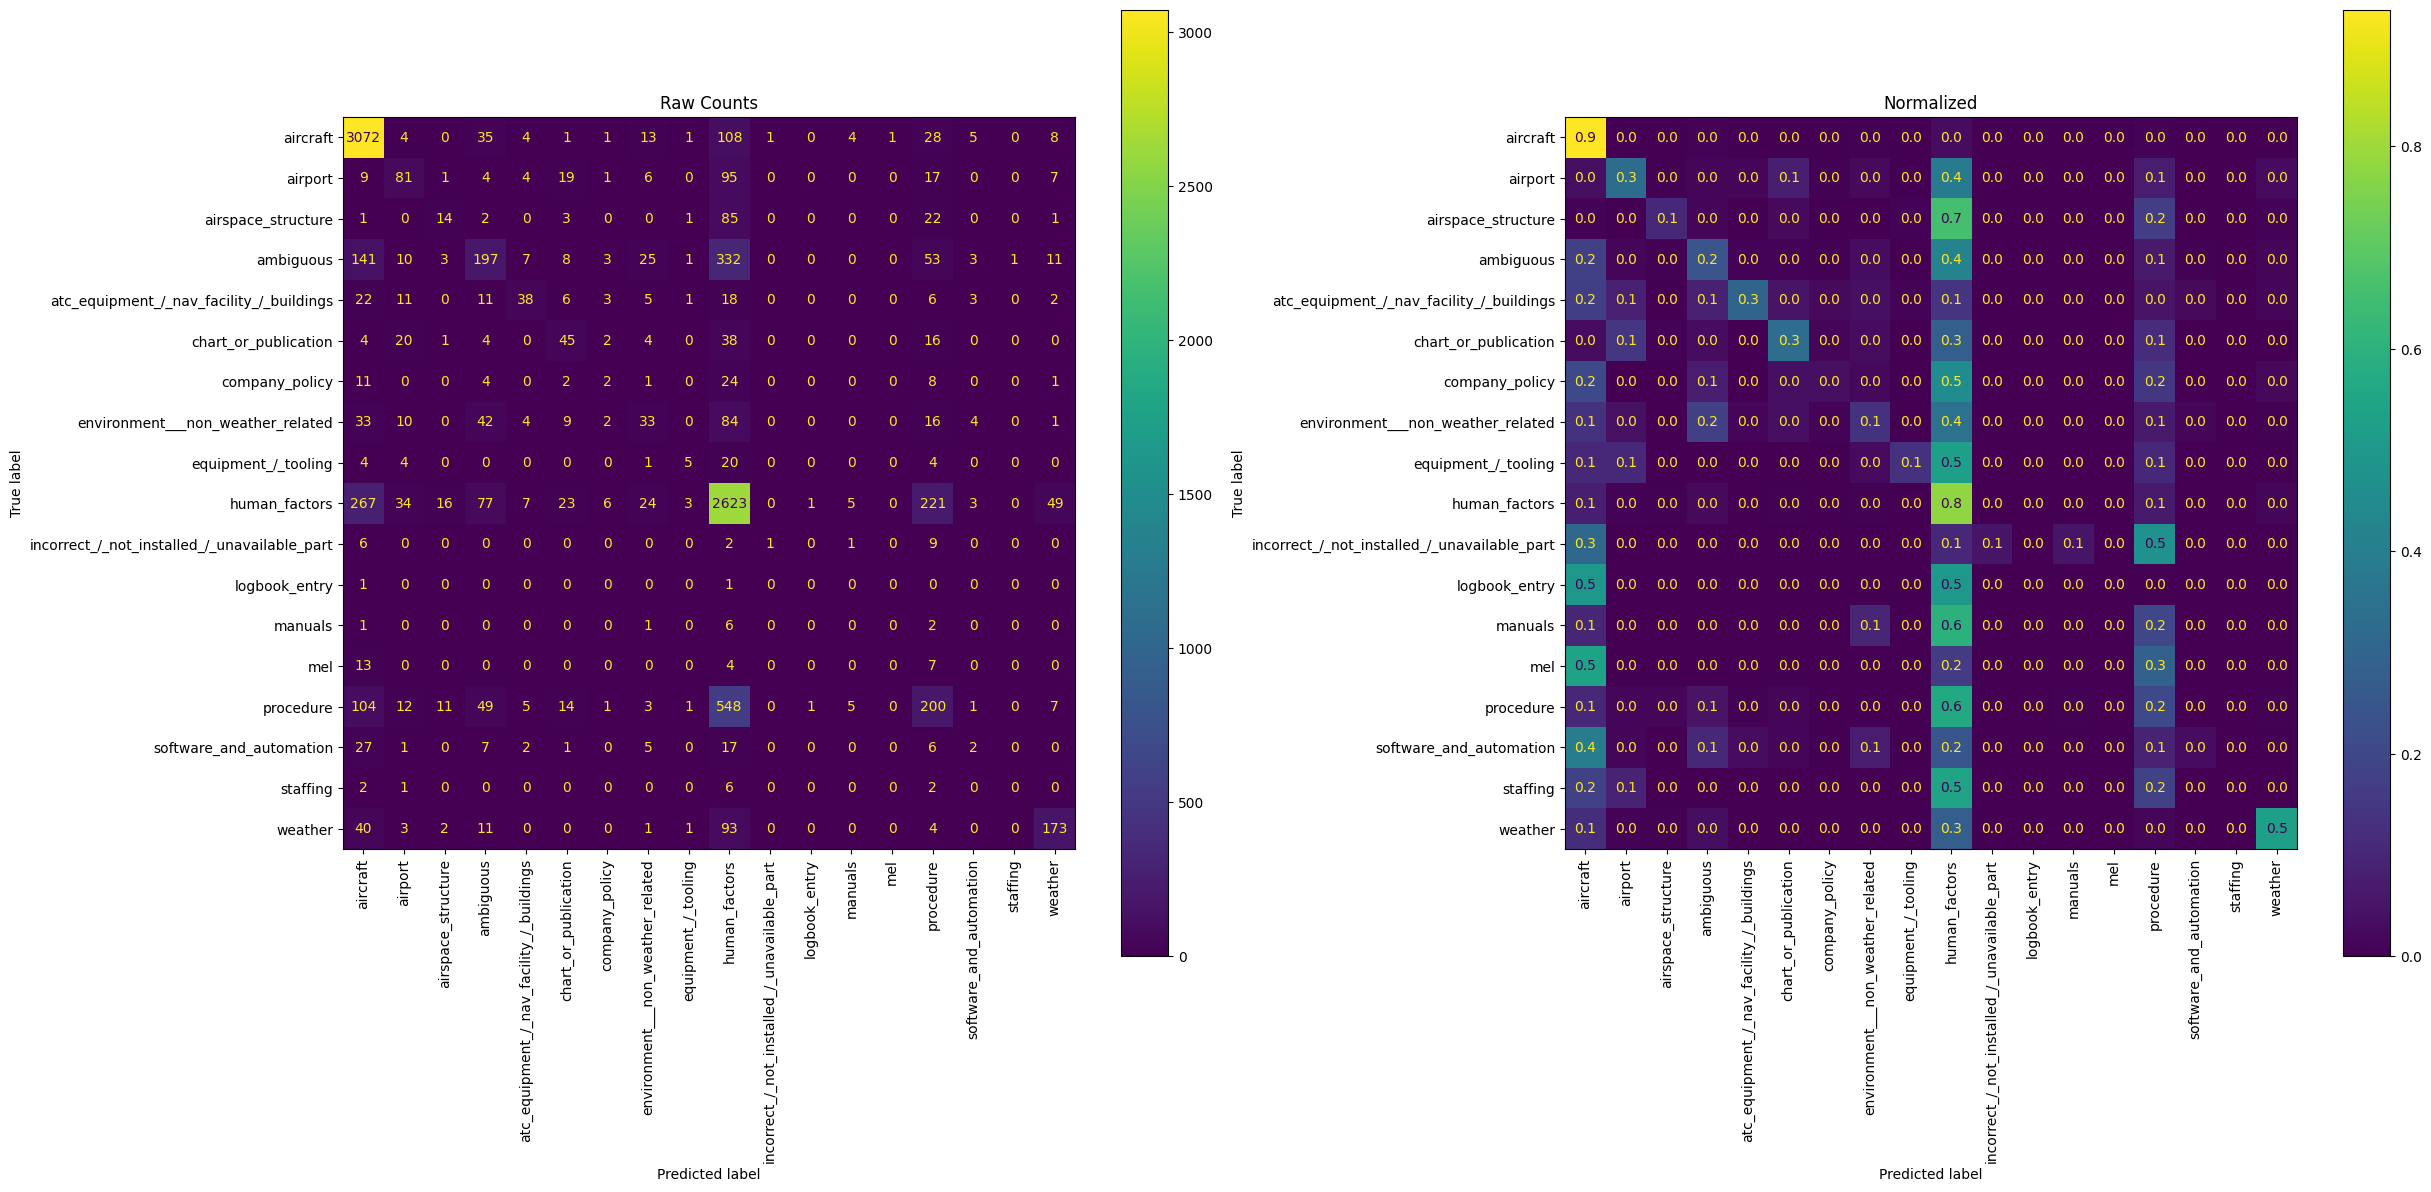

In [138]:
# ----- Random Forest -----
predY = rfc.predict(testX)
visualize_eval(testY, predY, "Random Forest Classifier Base")

/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maciej/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                                              precision    recall  f1-score   support

                                    aircraft       0.82      0.89      0.85      3286
                                     airport       0.21      0.43      0.28       244
                          airspace_structure       0.09      0.41      0.15       129
                                   ambiguous       0.43      0.29      0.34       795
    atc_equipment_/_nav_facility_/_buildings       0.28      0.33      0.30       126
                        chart_or_publication       0.23      0.20      0.21       134
                              company_policy       0.12      0.06      0.08        53
           environment___non_weather_related       0.26      0.08      0.12       238
                         equipment_/_tooling       0.15      0.47      0.23        38
                               human_factors       0.64      0.60      0.62      3359
incorrect_/_not_installed_/_unavailable_part       0.

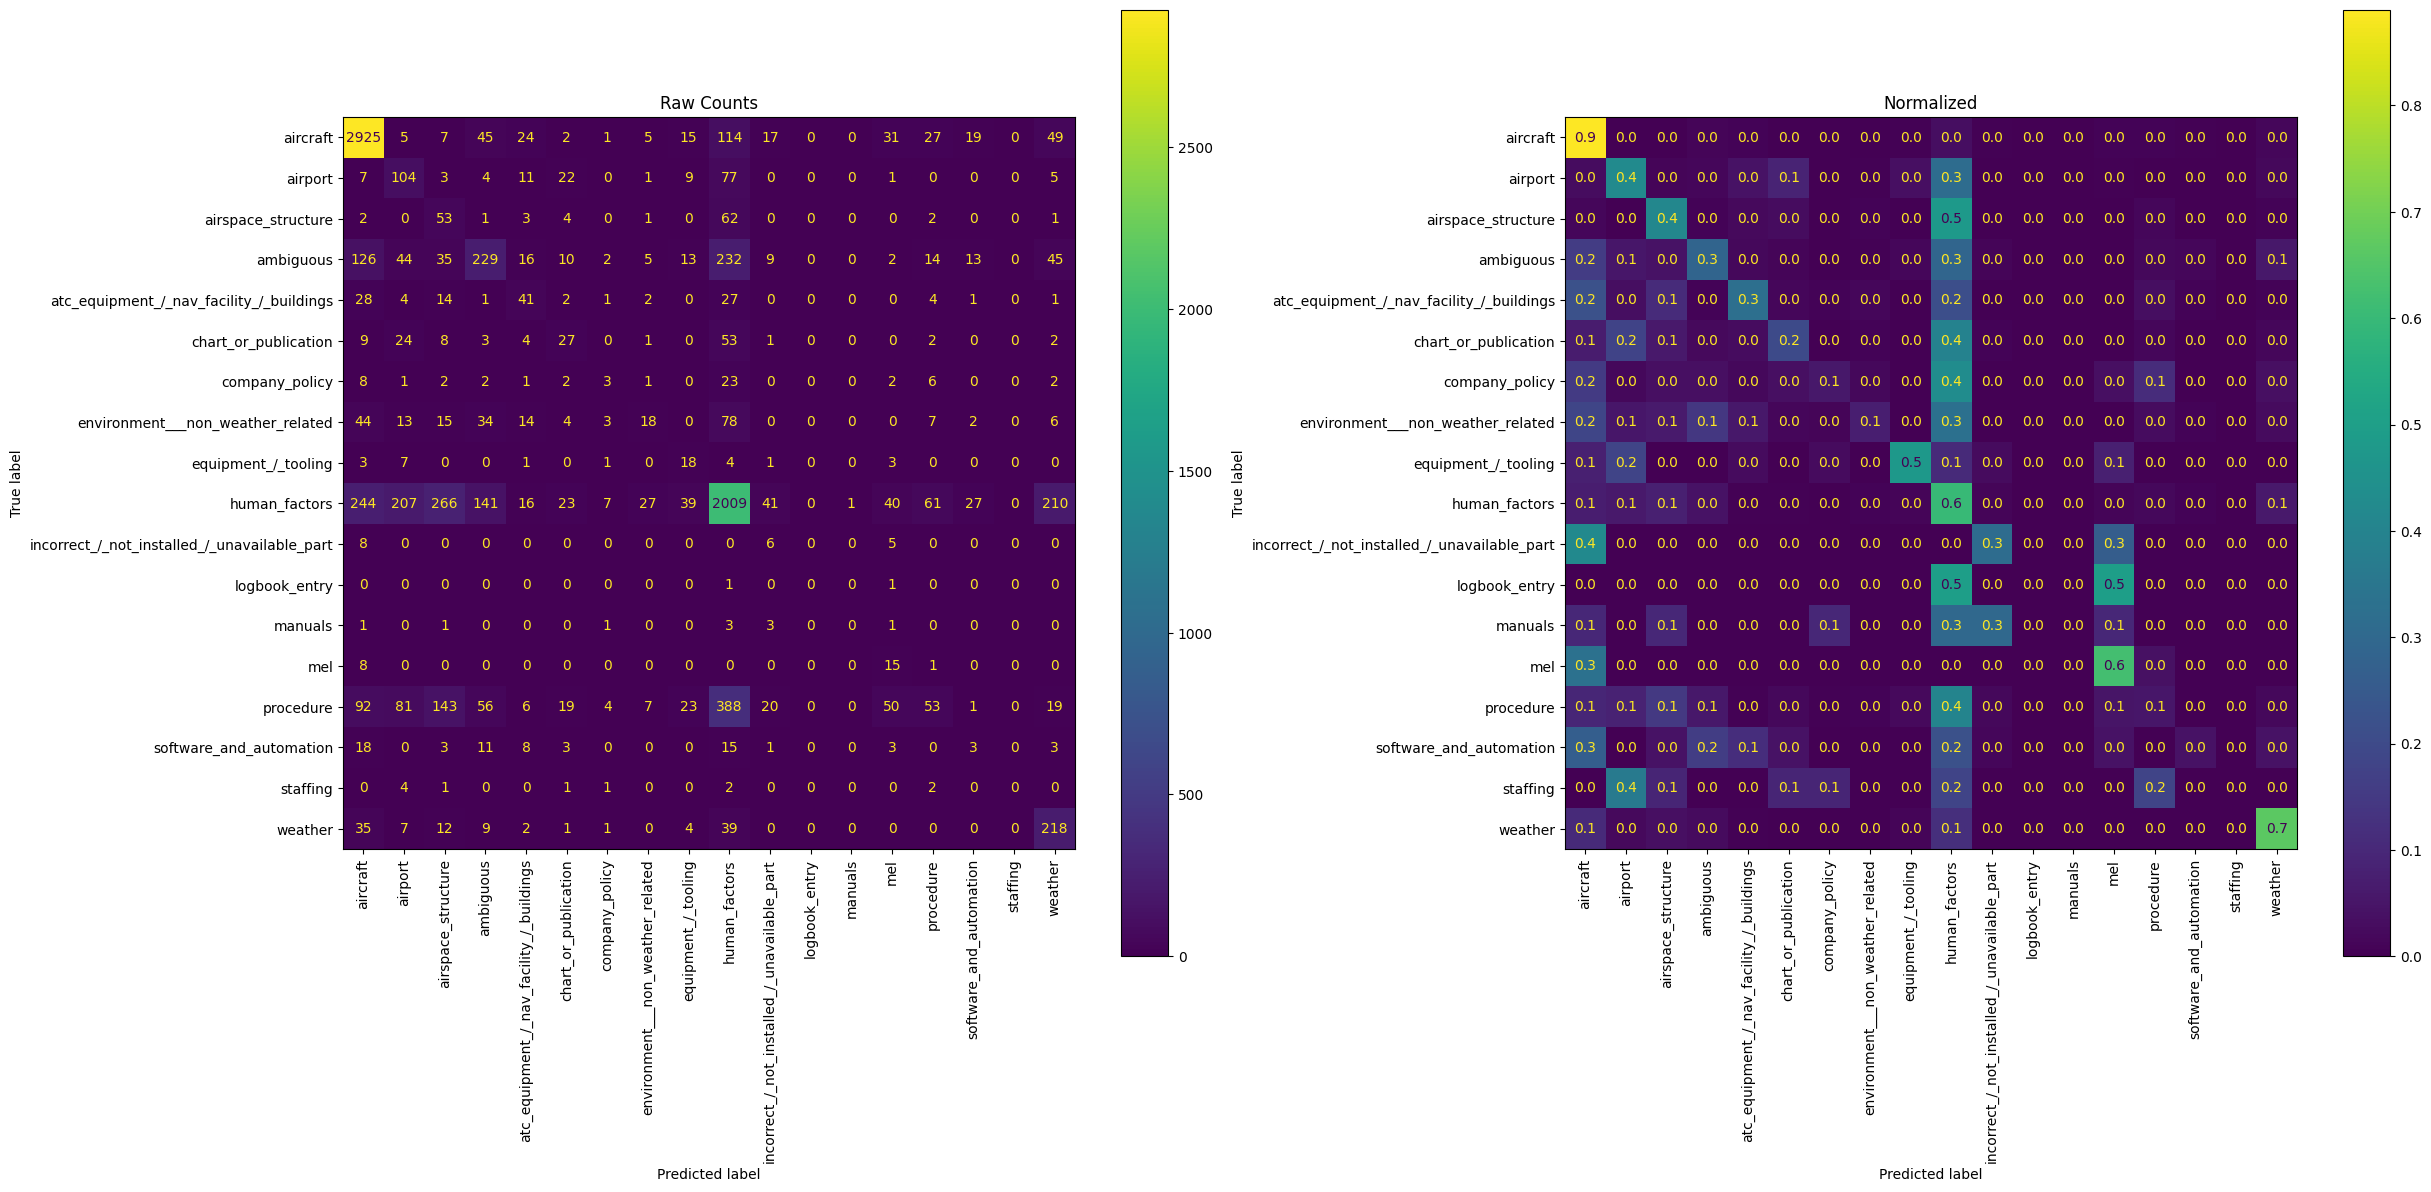

In [139]:
# ----- Naive Bayes -----
predY = nbc.predict(testX)
visualize_eval(testY, predY, "Naive Bayes Classifier Base")

### Models (With Oversampling)

In [140]:
rfc_bal = RandomForestClassifier(class_weight="balanced")
ros = RandomOverSampler()
rus = RandomUnderSampler() # Using this form of undersampling only leaves 2 entries per class
smt = SMOTE(k_neighbors=1) # logbook_entries has only 2 samples

In [141]:
oversampled_trainX, oversampled_trainY = ros.fit_resample(trainX, trainY)
undersampled_trainX, undersampled_trainY = rus.fit_resample(trainX, trainY)
smote_trainX, smote_trainY = smt.fit_resample(trainX, trainY)

#print("Oversampled:", oversampled_trainY.value_counts())
#print("Undersampled:", undersampled_trainY.value_counts())

In [142]:
rfc_bal.fit(smote_trainX, smote_trainY)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [143]:
rfc_bal.score(testX, testY)

0.5812131080806024

                                              precision    recall  f1-score   support

                                    aircraft       0.84      0.87      0.86      3286
                                     airport       0.29      0.38      0.33       244
                          airspace_structure       0.11      0.29      0.15       129
                                   ambiguous       0.34      0.31      0.32       795
    atc_equipment_/_nav_facility_/_buildings       0.34      0.49      0.40       126
                        chart_or_publication       0.32      0.31      0.31       134
                              company_policy       0.13      0.17      0.15        53
           environment___non_weather_related       0.20      0.20      0.20       238
                         equipment_/_tooling       0.14      0.18      0.16        38
                               human_factors       0.66      0.53      0.59      3359
incorrect_/_not_installed_/_unavailable_part       0.

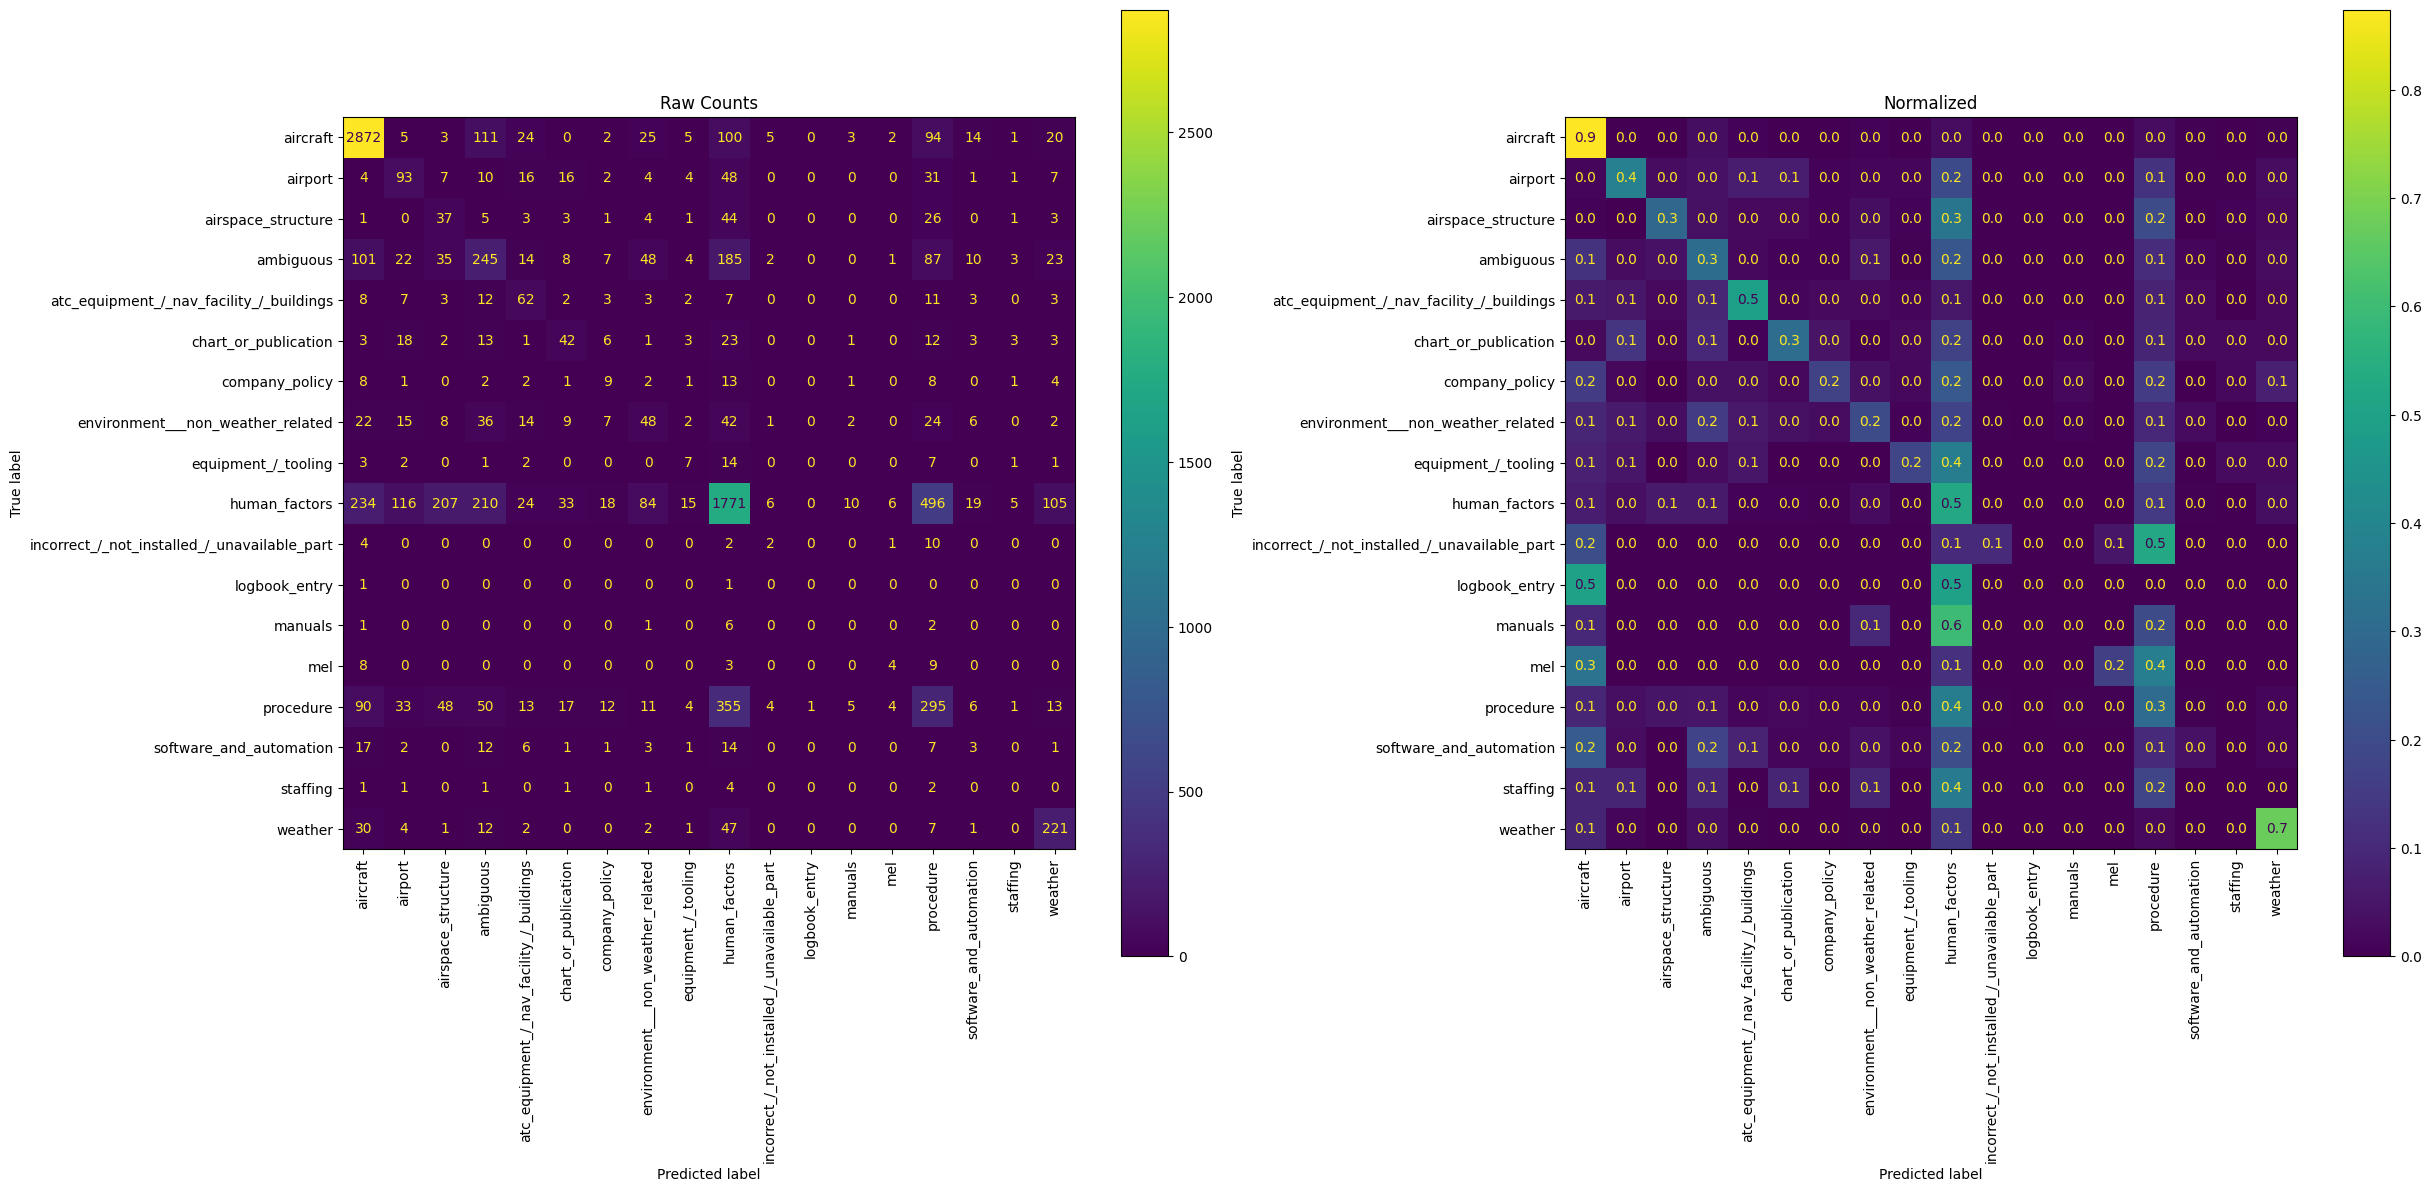

In [144]:
predY_bal = rfc_bal.predict(testX)
visualize_eval(testY, predY_bal, "Balanced RFC")

In [145]:
# Remove logbook_entries to allow SMOTE to use more neighbors
trainX_noLB = trainX.copy()
trainY_noLB = trainY.copy()

for index, value in trainY_noLB.items():
    if value == "logbook_entry":
        trainX_noLB.drop(index, inplace=True)
        trainY_noLB.drop(index, inplace=True)

testX_noLB = testX.copy()
testY_noLB = testY.copy()

for index, value in testY_noLB.items():
    if value == "logbook_entry":
        testX_noLB.drop(index, inplace=True)
        testY_noLB.drop(index, inplace=True)

In [146]:
rfc_bal_noLB = RandomForestClassifier(class_weight="balanced")
smt_defaultNeighbors = SMOTE(k_neighbors=10)

In [147]:
smote_trainXnoLB, smote_trainYnoLB = smt_defaultNeighbors.fit_resample(trainX_noLB, trainY_noLB)

In [148]:
rfc_bal_noLB.fit(smote_trainXnoLB, smote_trainYnoLB)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [149]:
rfc_bal_noLB.score(testX_noLB, testY_noLB)

0.5748167752442996

                                              precision    recall  f1-score   support

                                    aircraft       0.86      0.87      0.86      3286
                                     airport       0.28      0.41      0.33       244
                          airspace_structure       0.10      0.29      0.15       129
                                   ambiguous       0.36      0.31      0.33       795
    atc_equipment_/_nav_facility_/_buildings       0.31      0.54      0.40       126
                        chart_or_publication       0.31      0.33      0.32       134
                              company_policy       0.11      0.15      0.12        53
           environment___non_weather_related       0.24      0.25      0.25       238
                         equipment_/_tooling       0.19      0.42      0.26        38
                               human_factors       0.69      0.50      0.58      3359
incorrect_/_not_installed_/_unavailable_part       0.

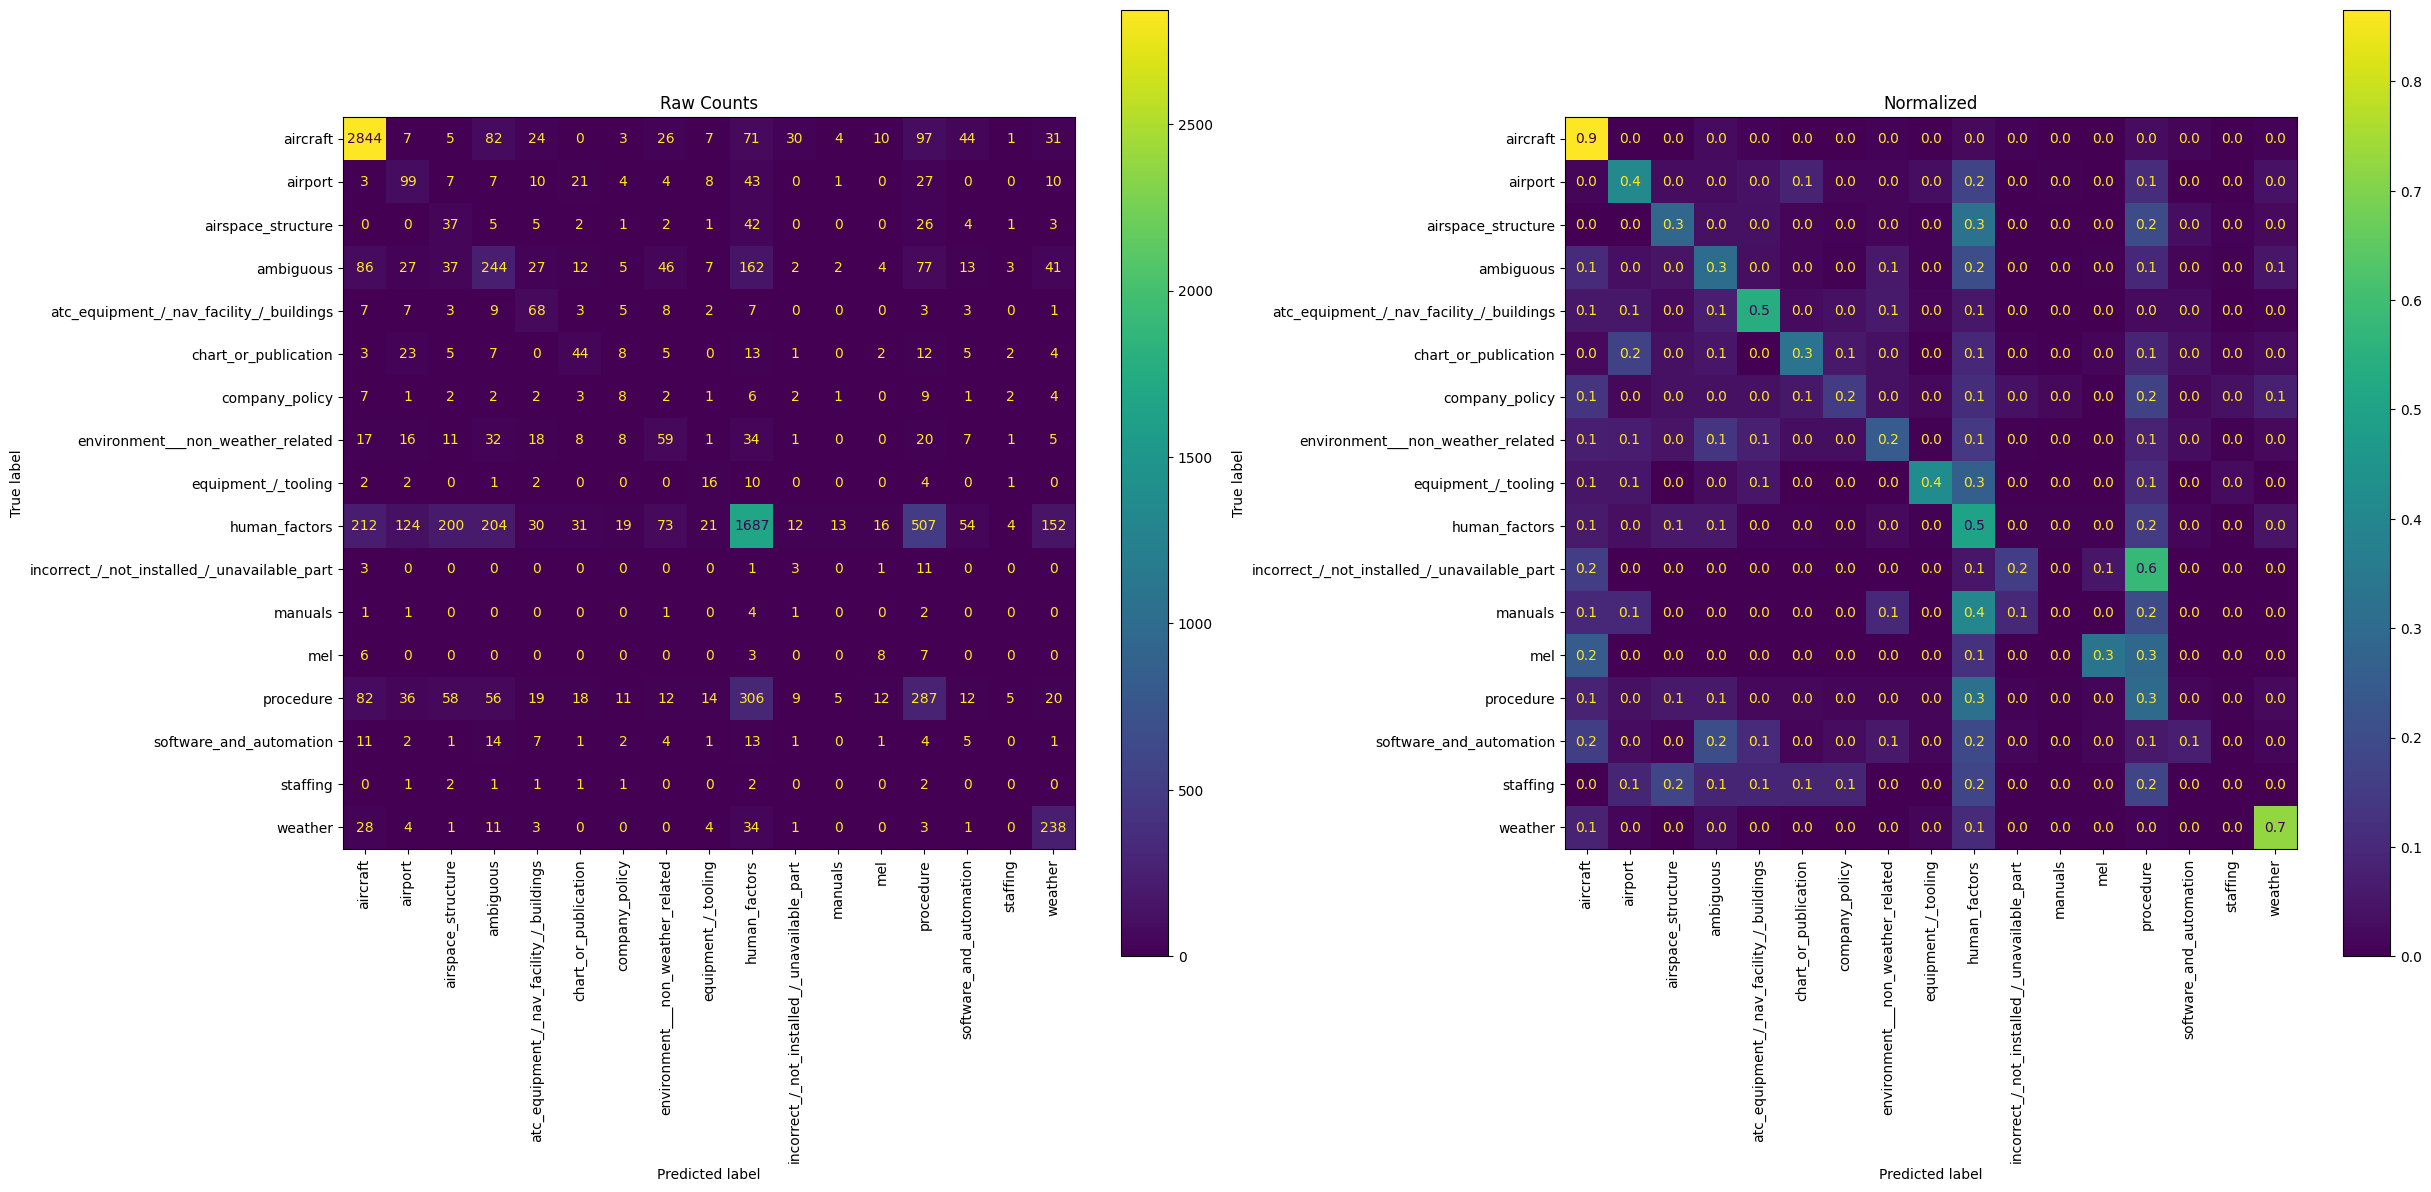

In [150]:
predY_bal_noLB = rfc_bal_noLB.predict(testX_noLB)
visualize_eval(testY_noLB, predY_bal_noLB, "RFC Balanced No Logbook")